# Линейная регрессия


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Задача та же:

https://www.kaggle.com/competitions/home-data-for-ml-course/overview

In [ ]:
df = pd.read_csv('data.csv')
df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [ ]:
# ищем признаки с наиболее высокой корреляцией с целевой переменной

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols.tolist()].corr()
corr_matrix["SalePrice"].sort_values(ascending=False)[:10]

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
# взаимная корреляция признаков
df['GarageCars'].corr(df['GarageArea'])

np.float64(0.8824754142814625)

In [ ]:
df['OverallQual'].corr(df['GrLivArea'])

np.float64(0.59300743002865)

In [ ]:
# берем признаки с наиболее высокой корреляцией с целевой переменной

X = df[['GrLivArea', 'OverallQual', 'GarageCars']]
y = df['SalePrice']

In [ ]:
X.isnull().sum()

,0
GrLivArea,0
OverallQual,0
GarageCars,0


In [ ]:
# разобьем данные на обучающую и тестовую выборку
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42) # размер тестовой выборки составит 25%

In [ ]:
print(X_train.shape, y_train.shape)

print(X_test.shape, y_test.shape)

(1095, 3) (1095,)
(365, 3) (365,)


## Обучение базовой модели

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Линейная регрессия:
* Хорошо работает, если зависимость между целевой переменной и признаками имеет линейный характер
* Хорошо интерпретируется
* Перед использованием лучше провести нормализацию данных, т.к масштаб влияет на веса


In [ ]:
# импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# создадим модель класса LinearRegression
model = LinearRegression()

# обучим нашу модель
model.fit(X_train, y_train)

LinearRegression()

Теперь сделаем предсказания с помощью метода **.predict(X)**. Заметьте, что в метод **.fit(X, y)** мы подавали матрицу с признаками и вектор с правильными ответами. В метод **.predict(X)** мы подаем только матрицу с признаками, потому что мы хотим сделать предсказание.

In [ ]:
y_pred = model.predict(X_test)

#print(y_pred)

### Интерпретирумость

In [ ]:
model.coef_

array([   46.81309582, 26942.08468451, 22968.28304684])

In [ ]:
model.intercept_

np.float64(-96101.25859671211)

In [ ]:
X_test[:1]

,GrLivArea,OverallQual,GarageCars
892,1068,6,1


In [ ]:
-96101.25859671211 + 1068*46.81309582 + 6*26942.08468451 + 1*22968.28304684

138515.91889294787

In [ ]:
y_pred[0]

np.float64(138515.91889362154)

## Оценка модели

Проверим результат. Воспользуемся метрикой RMSE

In [ ]:
from sklearn import metrics

# средняя абсолютная ошибка
print('MAE = ', metrics.mean_absolute_error(y_test, y_pred))

# корень среднеквадратической ошибки
print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# коэффициент детерминации r-квадрат
# ~ доля дисперсии зависимой переменной, объясняемая рассматриваемой моделью
# 1-(D[ошибки модели]/D[целевой переменной])
print('R2 = ', metrics.r2_score(y_test, y_pred))

# средняя абсолютная процентная ошибка
print('MAPE = ', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAE =  27359.27005740886
RMSE =  40895.843057058075
R2 =  0.7612567886938509
MAPE =  0.16946895878623014


In [ ]:
df.SalePrice.mean()

np.float64(180921.19589041095)

## Улучшения

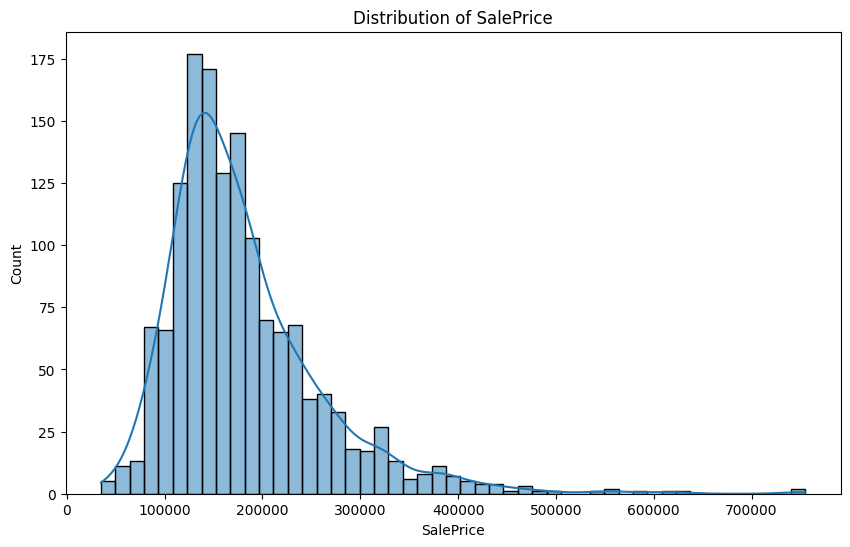

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.show()

In [ ]:
#добавим логарифм цены
df['logSalePrice'] = np.log1p(df['SalePrice'])

#обратная - np.expm1
df.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,logSalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016


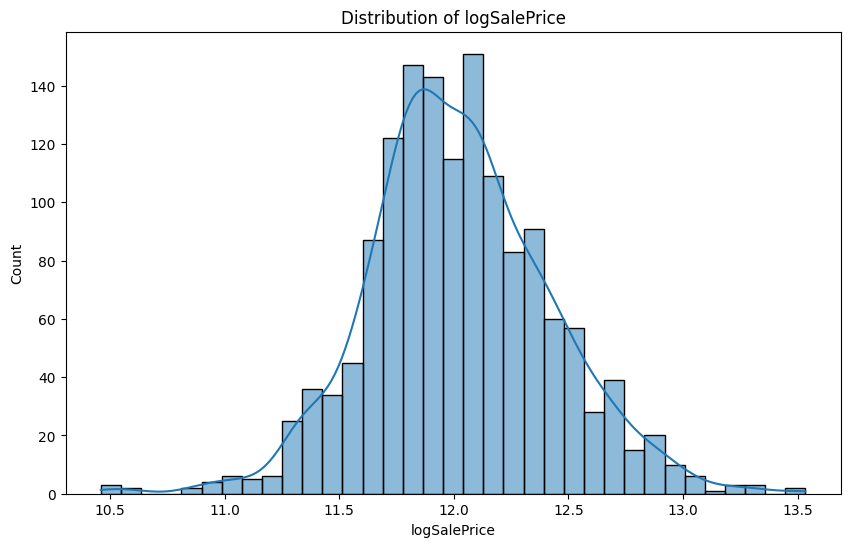

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['logSalePrice'], kde=True)
plt.title('Distribution of logSalePrice')
plt.xlabel('logSalePrice')
plt.show()

In [ ]:
X = df[['OverallQual', 'GrLivArea', 'GarageCars']]
y = df['logSalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

RMSE =  0.18826042557399486


In [ ]:
print('RMSE = ', np.sqrt(metrics.mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))
print('R2 = ', metrics.r2_score(np.expm1(y_test), np.expm1(y_pred)))

RMSE =  8.042555186507363
R2 =  0.2969037771859947


Что ещё можно применять:

* менять основание логарифма
* преобразование с помощью квадратного корня (и другие степени)
* преобразование Бокса-Кокса
* квантильное преобразование



In [ ]:
df_new = df[['OverallQual', 'GrLivArea', 'GarageCars', 'SalePrice']]

In [ ]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(n_quantiles = len(df_new),
                         output_distribution = 'normal',
                         random_state = 42)

X = df[['GrLivArea', 'OverallQual', 'GarageCars']]
y = df['SalePrice']
y_transformed = qt.fit_transform(y.values.reshape(-1, 1)).ravel()

print("До:", y.values[:5])
print("После:", y_transformed[:5])

До: [208500 181500 223500 140000 250000]
После: [ 0.62515224  0.31164299  0.76407051 -0.40790318  1.03159513]


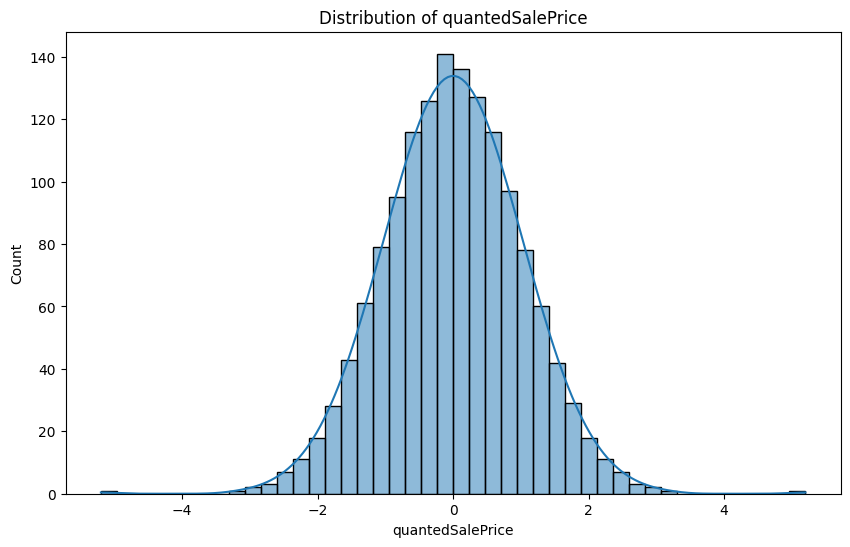

In [ ]:
# QT создан для случаев, когда распределение сильно ненормально и его форма мешает модели
plt.figure(figsize=(10, 6))
sns.histplot(y_transformed, kde=True)
plt.title('Distribution of quantedSalePrice')
plt.xlabel('quantedSalePrice')
plt.show()

In [ ]:
X = df_quanted[['GrLivArea', 'OverallQual', 'GarageCars']]
y = df_quanted['SalePrice']

#пример утечки данных

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size = 0.25, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_test = qt.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred = qt.inverse_transform(y_pred.reshape(-1, 1)).ravel()

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2 = ', metrics.r2_score(y_test, y_pred))

RMSE =  47998.84747153358
R2 =  0.6711223814135371


### Нормализация и устранение выбросов

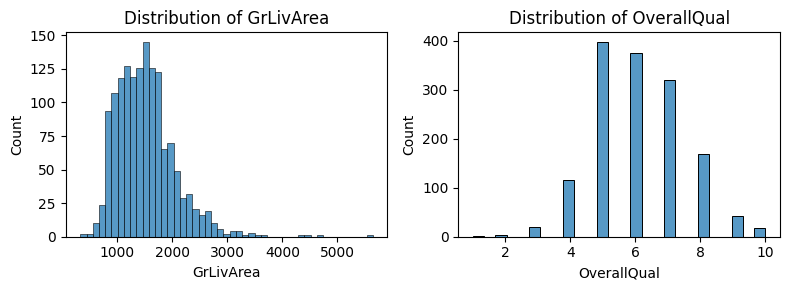

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sns.histplot(df['GrLivArea'], ax=axes[0])
axes[0].set_title('Distribution of GrLivArea')

sns.histplot(df['OverallQual'], ax=axes[1])
axes[1].set_title('Distribution of OverallQual')

plt.tight_layout()
plt.show()

<Axes: xlabel='GrLivArea'>

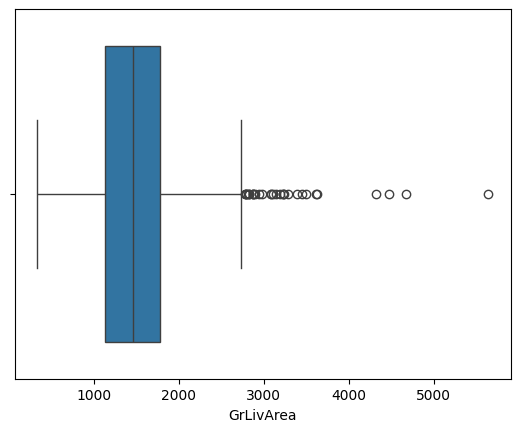

In [ ]:
sns.boxplot(x=df['GrLivArea'])

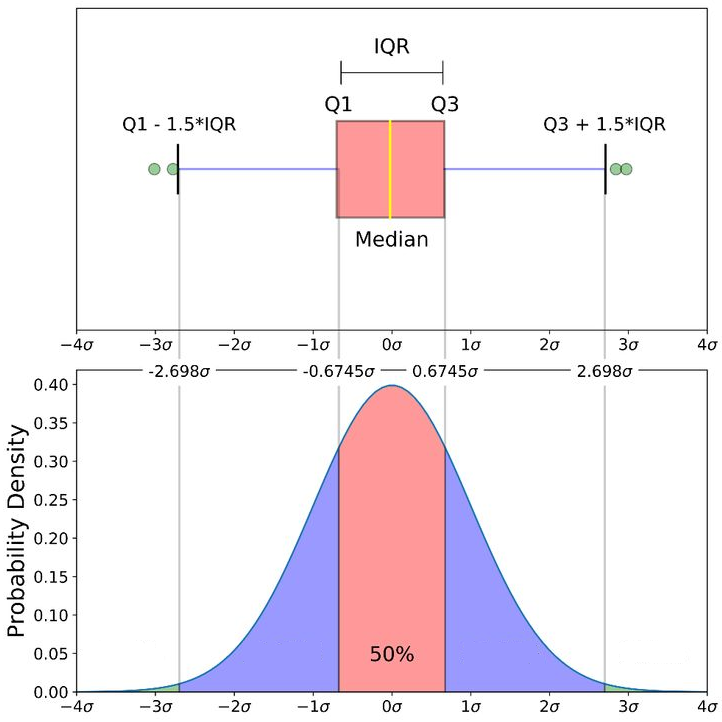

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

X = df[['OverallQual', 'GrLivArea', 'GarageCars']]
y = df['logSalePrice']

In [ ]:
scaler = MinMaxScaler() # приводит данные к заданному диапазону (по умолчанию от 0 до 1)
minmax_df = scaler.fit_transform(X)
minmax_df = pd.DataFrame(minmax_df, columns = ['OverallQual', 'GrLivArea', 'GarageCars'])

scaler = StandardScaler() #приводит к нулевому среднему и единичному стандартному отклонению
# (X - X.mean()) / X.std()
standard_df = scaler.fit_transform(X)
standard_df = pd.DataFrame(standard_df, columns = ['OverallQual', 'GrLivArea', 'GarageCars'])

scaler = RobustScaler() # использует медиану и межквартильный размах
                        # более устойчив к выбросам
robust_df = scaler.fit_transform(X)
robust_df = pd.DataFrame(robust_df, columns = ['OverallQual', 'GrLivArea', 'GarageCars'])

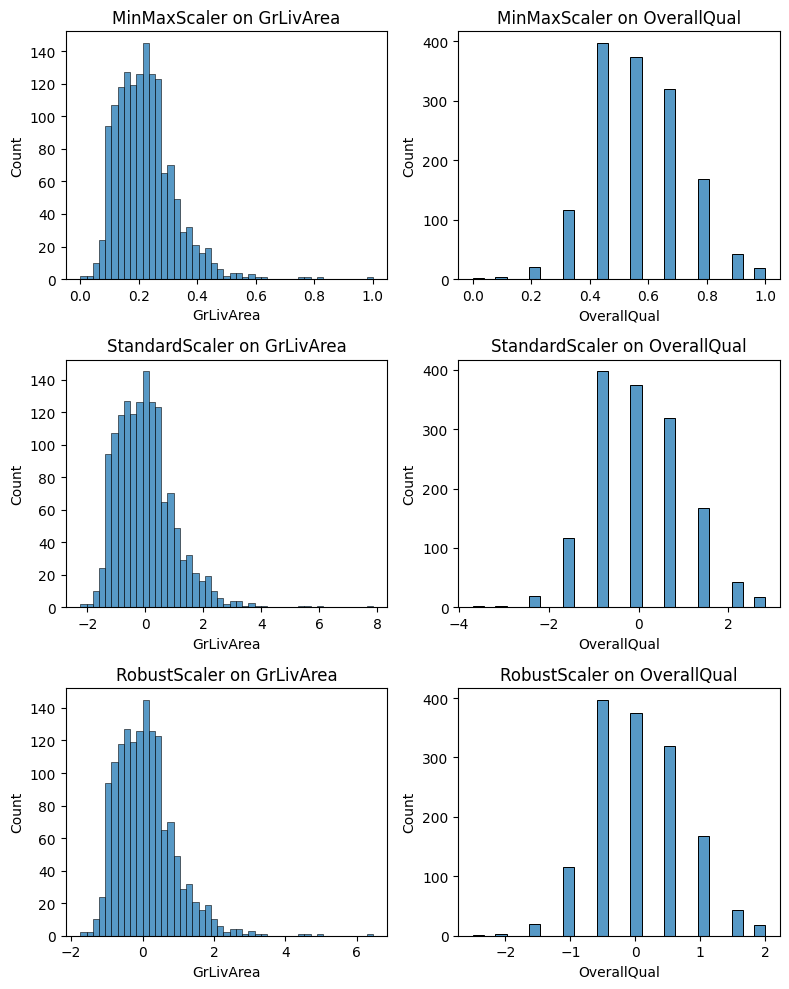

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

sns.histplot(minmax_df['GrLivArea'], ax=axes[0, 0])
axes[0, 0].set_title('MinMaxScaler on GrLivArea')

sns.histplot(minmax_df['OverallQual'], ax=axes[0, 1])
axes[0, 1].set_title('MinMaxScaler on OverallQual')

sns.histplot(standard_df['GrLivArea'], ax=axes[1, 0])
axes[1, 0].set_title('StandardScaler on GrLivArea')

sns.histplot(standard_df['OverallQual'], ax=axes[1, 1])
axes[1, 1].set_title('StandardScaler on OverallQual')

sns.histplot(robust_df['GrLivArea'], ax=axes[2, 0])
axes[2, 0].set_title('RobustScaler on GrLivArea')

sns.histplot(robust_df['OverallQual'], ax=axes[2, 1])
axes[2, 1].set_title('RobustScaler on OverallQual')

plt.tight_layout()
plt.show()

При обучении помнить про проблему утечки данных!

In [ ]:
#Неправильно
X = robust_df[['OverallQual', 'GarageCars', 'GrLivArea']]

y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

RMSE =  40895.84305705807


In [ ]:
#Правильно
X = df[['OverallQual', 'GarageCars', 'GrLivArea']]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

RMSE =  40895.84305705806


In [ ]:
# Ещё лучше
# используем pipeline

from sklearn.pipeline import Pipeline

# создадим объект pipe, в который поместим RobustScaler и LinearRegression
pipe = Pipeline(steps = [('scaler', RobustScaler()),
                         ('lr', LinearRegression())],
                verbose = True) # детальный вывод хода выполнения
pipe

Pipeline(steps=[('scaler', RobustScaler()), ('lr', LinearRegression())],
         verbose=True)

In [ ]:
pipe.fit(X_train, y_train) # ошибка утечки данных обрабатывается автоматически

y_pred = pipe.predict(X_test)
print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ................ (step 2 of 2) Processing lr, total=   0.0s
RMSE =  40895.84305705806


### Выбросы

In [ ]:
#Неправильно (хоть результат и кажется приятным)

df_filtered = df[df["GrLivArea"]<4000]

X = df_filtered[['OverallQual', 'GrLivArea', 'GarageCars']]
y = df_filtered['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

RMSE =  34374.339247037315


In [ ]:
X = df[['OverallQual', 'GrLivArea', 'GarageCars']]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

outliers = X_train[X_train["GrLivArea"]>4000].index
outliers

Index([1182, 523, 1298], dtype='int64')

In [ ]:
X_train = X_train.drop(outliers)
y_train = y_train.drop(outliers)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

RMSE =  40429.31924658323


In [ ]:
corr_matrix["SalePrice"].sort_values(ascending=False).index

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1',
       'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'HalfBath',
       'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch',
       'PoolArea', 'MoSold', '3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath',
       'MiscVal', 'Id', 'LowQualFinSF', 'YrSold', 'OverallCond', 'MSSubClass',
       'EnclosedPorch', 'KitchenAbvGr'],
      dtype='object')

In [ ]:
X = df[['Id', 'OverallQual', 'GrLivArea', 'GarageCars',
       'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
       'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces',
       'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF',
       'HalfBath', 'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr',
       'ScreenPorch', 'PoolArea', 'MoSold', '3SsnPorch', 'BsmtFinSF2',
       'BsmtHalfBath', 'MiscVal',  'LowQualFinSF', 'YrSold',
       'OverallCond', 'MSSubClass', 'EnclosedPorch', 'KitchenAbvGr']]

### Заполнение пропусков

In [184]:
df.duplicated(keep = 'first').sum() # поиск повторов

#df.drop_duplicates(keep = 'last', ignore_index = True, inplace = True)

np.int64(0)

In [ ]:
X.isnull().sum().sort_values(ascending=False)[:4]

,0
LotFrontage,259
GarageYrBlt,81
MasVnrArea,8
OverallQual,0


In [ ]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

<Axes: xlabel='LotFrontage', ylabel='Count'>

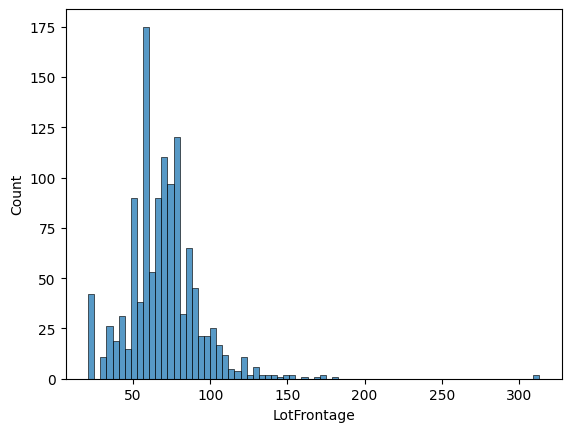

In [ ]:
sns.histplot(x=df['LotFrontage'])

In [ ]:
df['LotFrontage'].mean()

np.float64(70.04995836802665)

In [ ]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [ ]:
df['GarageYrBlt'].mode()

,GarageYrBlt
0,2005.0


Также есть библиотека SimpleImputer

<Axes: xlabel='GarageYrBlt', ylabel='Count'>

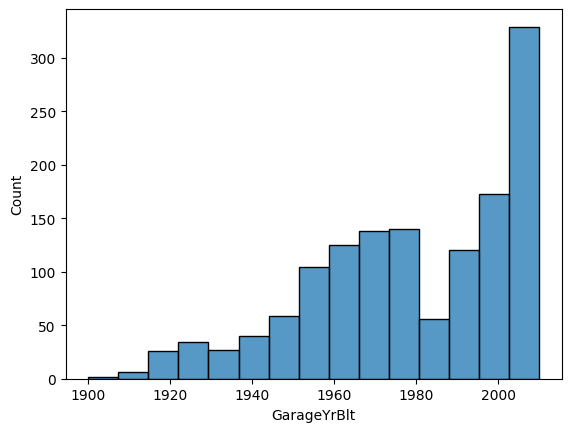

In [ ]:
sns.histplot(x=X['GarageYrBlt'])

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean') # 'median' 'most_frequent'

df['GarageYrBlt'] = imputer.fit_transform(df['GarageYrBlt'].values.reshape(-1,1))

In [ ]:
from sklearn.impute import KNNImputer

imputer=KNNImputer(n_neighbors=1)

X = pd.DataFrame(imputer.fit_transform(X), columns = X.columns)

## Регуляризация

In [ ]:
X.columns

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces', 'BsmtFinSF1',
       'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF', 'HalfBath',
       'LotArea', 'BsmtFullBath', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch',
       'PoolArea', 'MoSold', '3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath',
       'MiscVal', 'LowQualFinSF', 'YrSold', 'OverallCond', 'MSSubClass',
       'EnclosedPorch', 'KitchenAbvGr'],
      dtype='object')

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

RMSE =  29837.545686482197


In [ ]:
model.coef_

array([-4.11058363e-03,  1.71042379e-01,  7.51410314e-02,  7.39660257e-02,
        9.72397671e-03,  1.80764228e-02,  4.02562295e-02,  3.31116764e-02,
        2.89169419e-02,  1.36108334e-01,  4.89413408e-02, -1.52295747e-02,
       -3.28966230e-03,  4.90593994e-02,  1.23676141e-02, -9.89549598e-03,
        2.07131913e-02,  3.86462001e-02, -2.29995905e-03,  2.18712134e-02,
        7.53374695e-03,  7.25233092e-02,  4.69346706e-04,  2.00353016e-03,
        3.27645409e-04, -3.99261405e-04,  1.08052735e-03,  2.92688557e-04,
        1.47629217e-06,  1.60424724e-02, -2.19411152e-06,  1.14050215e-04,
       -1.09812426e-02,  4.43492322e-02, -3.71482979e-02,  1.55305782e-04,
       -4.58182686e-02])

In [ ]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

RMSE =  29839.777000472583


In [ ]:
model.coef_

array([-4.11492817e-03,  1.70633745e-01,  7.48285845e-02,  7.37289581e-02,
        1.00378998e-02,  1.83727536e-02,  4.00273640e-02,  3.32808398e-02,
        2.89690550e-02,  1.35214009e-01,  4.91732316e-02, -1.46355412e-02,
       -3.19904231e-03,  4.91854824e-02,  1.26036390e-02, -9.84568350e-03,
        2.07559016e-02,  3.85285071e-02, -2.27470127e-03,  2.20787790e-02,
        7.53665427e-03,  7.20160555e-02,  4.36521432e-04,  2.04416614e-03,
        3.27870011e-04, -3.98766843e-04,  1.09967457e-03,  2.93050318e-04,
        1.77683666e-06,  1.55751251e-02, -2.22444249e-06,  1.13029004e-04,
       -1.09718709e-02,  4.42520104e-02, -3.70584195e-02,  1.54215807e-04,
       -4.54034228e-02])

In [ ]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=1, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

RMSE =  87927.05711747566


In [ ]:
model.coef_

array([-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        4.58890680e-04,  2.55288984e-04,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00, -1.02512804e-05, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -7.69176311e-04,
       -0.00000000e+00])

In [ ]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.05, l1_ratio=0.05, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('RMSE = ', np.sqrt(metrics.mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

RMSE =  30792.000992551522


In [ ]:
model.coef_

array([-0.00000000e+00,  1.54833204e-01,  8.20265516e-02,  6.39375178e-02,
        2.29395690e-02,  2.83078422e-02,  1.87332455e-02,  2.83391014e-02,
        2.93141030e-02,  1.05680968e-01,  5.46548148e-02,  1.84911643e-03,
        1.54519554e-04,  4.95725195e-02,  1.78717707e-02, -2.52044469e-03,
        2.22071878e-02,  1.72209537e-02,  0.00000000e+00,  1.90545728e-02,
        7.86326644e-03,  4.52324902e-02, -0.00000000e+00,  0.00000000e+00,
        3.52940098e-04, -3.73465768e-04,  0.00000000e+00,  3.13034034e-04,
        1.29685931e-05,  0.00000000e+00, -3.66789544e-06,  3.96397851e-05,
       -4.75597654e-03,  3.75498908e-02, -2.77332482e-02,  8.16284566e-05,
       -8.21072559e-03])